In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms


In [3]:
class CEDARDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for label, subfolder in enumerate(['original', 'forged']):
            class_dir = os.path.join(root_dir, subfolder)
            for filename in os.listdir(class_dir):
                if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(class_dir, filename), label))

        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        image = Image.open(image_path).convert('L')  # Grayscale
        if self.transform:
            image = self.transform(image)
        return image, label


In [60]:
transform = transforms.Compose([
    transforms.Resize((128, 256)),  # Resize for uniformity
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])



# transform = transforms.Compose([
#     transforms.Grayscale(num_output_channels=3),  # Convert grayscale to 3-channel RGB
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(15),
#     transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
# ])

dataset = CEDARDataset(root_dir='/kaggle/input/processed-signatures/CEDAR', transform=transform)


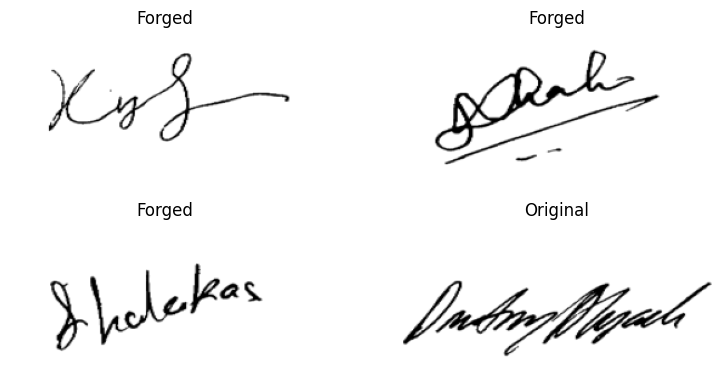

In [62]:
def show_images(dataset):
    fig, axs = plt.subplots(2, 2, figsize=(8, 4))
    for i in range(4):
        image, label = dataset[i]
        axs[i // 2, i % 2].imshow(image.squeeze(), cmap='gray')
        axs[i // 2, i % 2].set_title('Original' if label == 0 else 'Forged')
        axs[i // 2, i % 2].axis('off')
    plt.tight_layout()
    plt.savefig('signatures_example.png')
    plt.show()

show_images(dataset)


In [52]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)


In [53]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Total images: 2640
Train: 1847, Val: 396, Test: 397


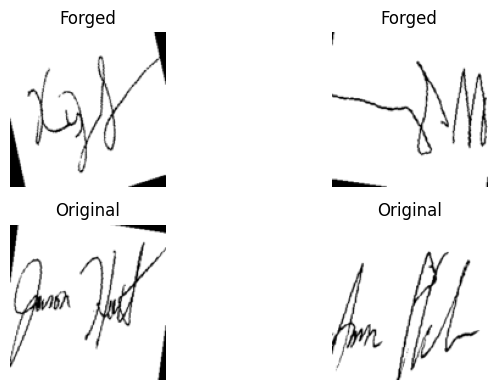

In [42]:
print(f"Total images: {len(dataset)}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Show a few images from train loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

fig, axs = plt.subplots(2, 2, figsize=(8, 4))
for i in range(4):
    axs[i // 2, i % 2].imshow(images[i].squeeze(), cmap='gray')
    axs[i // 2, i % 2].set_title('Original' if labels[i] == 0 else 'Forged')
    axs[i // 2, i % 2].axis('off')
plt.tight_layout()
plt.show()


## 1- Model 1

In [9]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 32 * 64, 128)
        self.fc2 = nn.Linear(128, 2)  # binary classification

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   
        x = self.pool(F.relu(self.conv2(x)))  
        x = x.view(x.size(0), -1)              
        x = F.relu(self.fc1(x))
        return self.fc2(x)


## 2- Model 2

In [31]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Define layers
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)   
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.dropout = nn.Dropout(0.3)  # 30% dropout

        # Manually compute flattened size
        self._to_linear = 16 * 32 * 32 * 2  
        self.fc1 = nn.Linear(self._to_linear, 64)  
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        # Forward pass
        x = self.pool(F.relu(self.conv1(x)))  
        x = self.pool(F.relu(self.conv2(x)))  
        
        x = x.view(x.size(0), -1)  
        
        x = self.dropout(x)  
        x = F.relu(self.fc1(x))  
        x = self.fc2(x)  
        return x



## 3- Model 3

In [54]:
from torchvision import datasets, transforms, models
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        
        self.model = models.resnet18(pretrained=True)
        
        
        self.model.fc = nn.Linear(self.model.fc.in_features, 2)
        
        
        self.dropout = nn.Dropout(0.5)  

    def forward(self, x):
        x = self.model(x)
        x = self.dropout(x)  
        return x

In [55]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)



#criterion = nn.CrossEntropyLoss()
#optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


class_weights = torch.tensor([1.0, 2.0])  
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

In [56]:
def count_parameters(model):
    print(f"{'Layer':<30} {'Parameters':>12}")
    print('-' * 45)
    total = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            num_params = param.numel()
            total += num_params
            print(f"{name:<30} {num_params:>12,}")
    print('-' * 45)
    print(f"{'Total Trainable Params':<30} {total:>12,}")

count_parameters(model)


Layer                            Parameters
---------------------------------------------
model.conv1.weight                    9,408
model.bn1.weight                         64
model.bn1.bias                           64
model.layer1.0.conv1.weight          36,864
model.layer1.0.bn1.weight                64
model.layer1.0.bn1.bias                  64
model.layer1.0.conv2.weight          36,864
model.layer1.0.bn2.weight                64
model.layer1.0.bn2.bias                  64
model.layer1.1.conv1.weight          36,864
model.layer1.1.bn1.weight                64
model.layer1.1.bn1.bias                  64
model.layer1.1.conv2.weight          36,864
model.layer1.1.bn2.weight                64
model.layer1.1.bn2.bias                  64
model.layer2.0.conv1.weight          73,728
model.layer2.0.bn1.weight               128
model.layer2.0.bn1.bias                 128
model.layer2.0.conv2.weight         147,456
model.layer2.0.bn2.weight               128
model.layer2.0.bn2.bias       

In [57]:
from tqdm import tqdm
import numpy as np

EPOCHS = 10

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]", leave=False)
    
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        loop = tqdm(val_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]", leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            loop.set_postfix(loss=loss.item(), acc=100 * val_correct / val_total)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


Epoch [1/10] Train Loss: 0.8663 | Train Acc: 56.69% | Val Loss: 0.5924 | Val Acc: 61.62%


Epoch [2/10] Train Loss: 0.6123 | Train Acc: 63.29% | Val Loss: 0.5383 | Val Acc: 73.48%


Epoch [3/10] Train Loss: 0.5856 | Train Acc: 65.35% | Val Loss: 0.6600 | Val Acc: 67.17%


Epoch [4/10] Train Loss: 0.5732 | Train Acc: 66.00% | Val Loss: 0.5274 | Val Acc: 66.41%


Epoch [5/10] Train Loss: 0.5544 | Train Acc: 66.38% | Val Loss: 0.4695 | Val Acc: 76.77%


Epoch [6/10] Train Loss: 0.5632 | Train Acc: 67.30% | Val Loss: 0.7411 | Val Acc: 62.12%


Epoch [7/10] Train Loss: 0.5090 | Train Acc: 70.22% | Val Loss: 0.5302 | Val Acc: 69.19%


Epoch [8/10] Train Loss: 0.4829 | Train Acc: 72.82% | Val Loss: 0.4813 | Val Acc: 70.71%


Epoch [9/10] Train Loss: 0.5002 | Train Acc: 71.79% | Val Loss: 0.3911 | Val Acc: 76.52%


Epoch [10/10] Train Loss: 0.4951 | Train Acc: 71.03% | Val Loss: 0.4709 | Val Acc: 70.96%


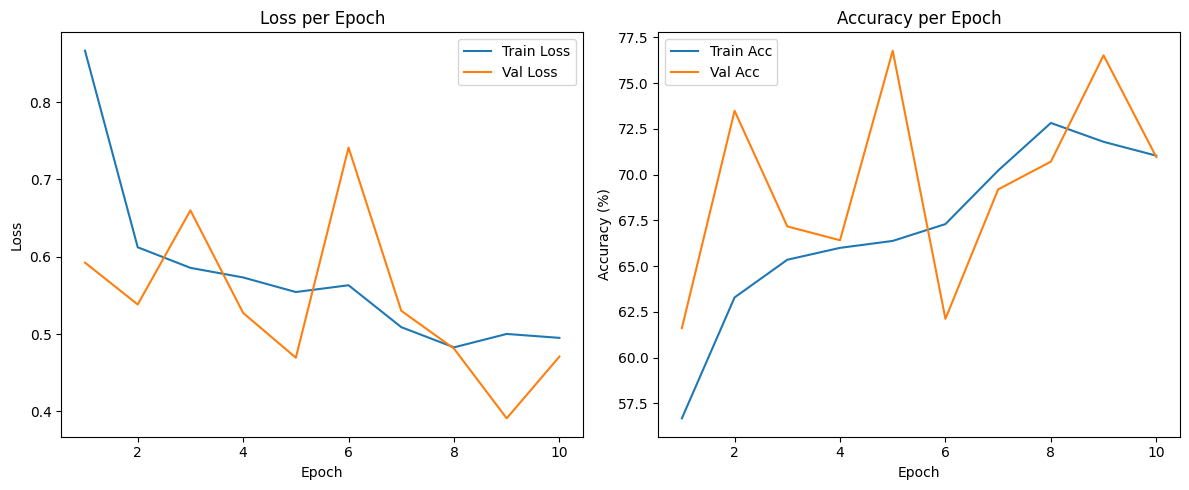

In [58]:
import matplotlib.pyplot as plt
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(epochs,train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Acc')
plt.plot(epochs, val_accuracies, label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('model3cnn_losses.png')
plt.show()


In [59]:
from tqdm import tqdm

model.eval()
test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    loop = tqdm(test_loader, desc="Testing", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

avg_test_loss = test_loss / len(test_loader)
test_accuracy = 100 * correct / total

print(f"\nTest Loss: {avg_test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")



Test Loss: 0.4477 | Test Accuracy: 73.55%
